# Exploratory Data Anlysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
# Import data from CSV file

df = pd.read_csv('D:\REVISION MATERIALS\Python\Python_Diwali_Sales_Analysis\Diwali Sales Data.csv', encoding = 'unicode_escape')

## Exploring the Data

In [14]:
df.shape

(11251, 15)

df.head()

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


### Handling Missing values

In [17]:
df.drop(['Status','unnamed1'], axis = 1, inplace = True)


In [20]:
df.dropna(inplace = True)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11239 entries, 0 to 11250
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11239 non-null  int64  
 1   Cust_name         11239 non-null  object 
 2   Product_ID        11239 non-null  object 
 3   Gender            11239 non-null  object 
 4   Age Group         11239 non-null  object 
 5   Age               11239 non-null  int64  
 6   Marital_Status    11239 non-null  int64  
 7   State             11239 non-null  object 
 8   Zone              11239 non-null  object 
 9   Occupation        11239 non-null  object 
 10  Product_Category  11239 non-null  object 
 11  Orders            11239 non-null  int64  
 12  Amount            11239 non-null  float64
dtypes: float64(1), int64(4), object(8)
memory usage: 1.2+ MB


### Handling Duplicate values

In [29]:
df.duplicated().sum()

np.int64(0)

In [27]:
df[df.duplicated()]

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
19,1001883,Praneet,P00029842,M,51-55,54,1,Uttar Pradesh,Central,Hospitality,Auto,1,23568.0
4404,1004725,Jackson,P00150842,F,36-45,37,1,Maharashtra,Western,Hospitality,Electronics & Gadgets,4,9859.0
5703,1003208,Bowman,P00171642,F,26-35,31,0,Bihar,Eastern,Agriculture,Electronics & Gadgets,4,8088.0
5908,1001260,Dheeraj,P00344042,M,26-35,28,0,Maharashtra,Western,IT Sector,Electronics & Gadgets,4,8015.0
6173,1001325,Reese,P00111742,F,26-35,27,1,Gujarat,Western,Construction,Electronics & Gadgets,3,7923.0
8651,1000083,Gute,P00242842,M,26-35,35,0,Uttar Pradesh,Central,Hospitality,Clothing & Apparel,3,5345.0
8941,1001476,Anudeep,P00036842,M,18-25,25,0,Maharashtra,Western,IT Sector,Clothing & Apparel,4,5202.0
10571,1004404,Rittenbach,P00150142,F,26-35,28,1,Haryana,Northern,Aviation,Electronics & Gadgets,3,2304.0


In [28]:
df.drop_duplicates(inplace = True)

In [30]:
df['User_ID'].duplicated().sum()

np.int64(7479)

In [34]:
df[['Age','Orders','Orders']].describe()

,Age,Orders,Orders
count,11231.000000,11231.000000,11231.000000
mean,35.411985,2.489093,2.489093
std,12.756116,1.114880,1.114880
min,12.000000,1.000000,1.000000
25%,27.000000,2.000000,2.000000
50%,33.000000,2.000000,2.000000
75%,43.000000,3.000000,3.000000
max,92.000000,4.000000,4.000000


In [35]:
df['Amount'] = df['Amount'].astype(int)

In [36]:
df['Amount'].dtype

dtype('int64')

In [37]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='object')

In [38]:
df.rename(columns = {'Cust_name': 'Customer_name'}, inplace = True)

In [41]:
df['Marital_Status'] = df['Marital_Status'].astype(str)

df.loc[df.Marital_Status == 0, 'Marital_Status'] = 'Unmaried'
df.loc[df.Marital_Status == 1, 'Marital_Status'] = 'Married'

In [42]:
df.head()

,User_ID,Customer_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,Unmaried,Maharashtra,Western,Healthcare,Auto,1,23952
1,1000732,Kartik,P00110942,F,26-35,35,Married,Andhra Pradesh,Southern,Govt,Auto,3,23934
2,1001990,Bindu,P00118542,F,26-35,35,Married,Uttar Pradesh,Central,Automobile,Auto,3,23924
3,1001425,Sudevi,P00237842,M,0-17,16,Unmaried,Karnataka,Southern,Construction,Auto,2,23912
4,1000588,Joni,P00057942,M,26-35,28,Married,Gujarat,Western,Food Processing,Auto,2,23877


## Analysis by Gender

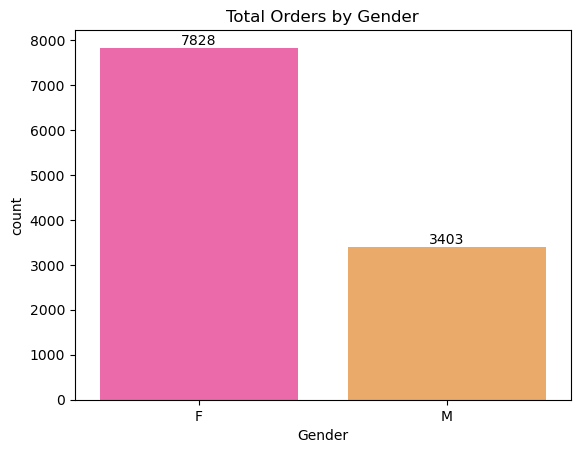

In [51]:
ax = sns.countplot(x = 'Gender', data = df, hue = 'Gender', palette = 'spring')

for bars in ax.containers:
    ax.bar_label(bars)
plt.title('Total Orders by Gender')
plt.show()

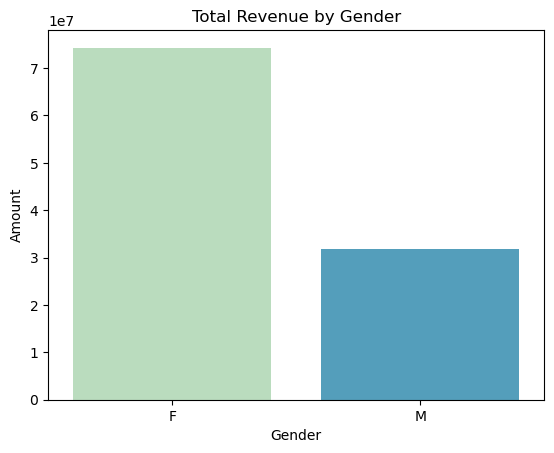

In [49]:
Gender_sales = df.groupby(['Gender'], as_index = False)['Amount'].sum().sort_values(by = 'Amount', ascending = False)
sns.barplot(data = Gender_sales, x = 'Gender', y = 'Amount', hue = 'Gender', palette = 'GnBu')

plt.title('Total Revenue by Gender')
plt.show()

*From the above charts we can analyse that most of our buyers are female and their purchasing power is also greater than Men*

## Analysis by Age Group

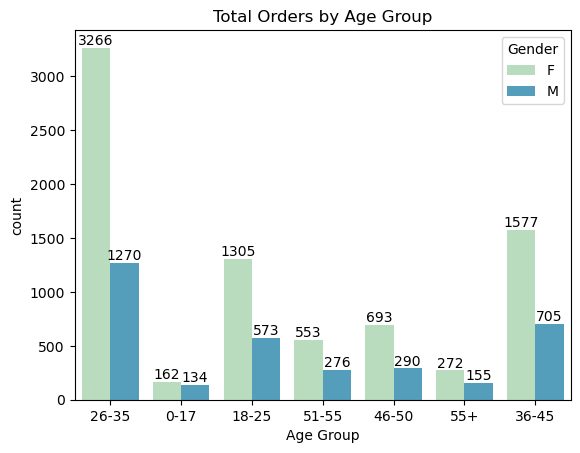

In [55]:
ax = sns.countplot(x = 'Age Group', data = df, hue = 'Gender', palette = 'GnBu')

for bars in ax.containers:
    ax.bar_label(bars)
plt.title('Total Orders by Age Group')
plt.show()

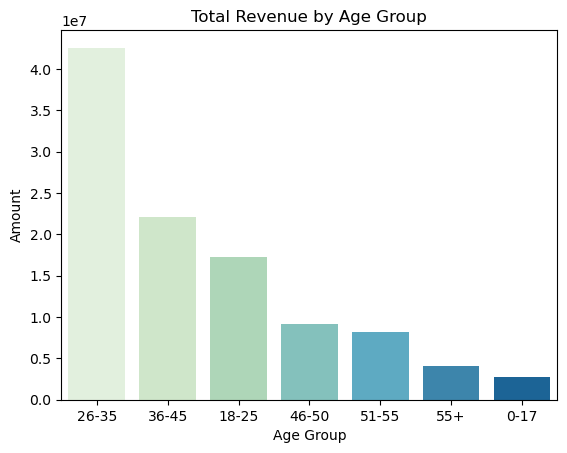

In [57]:
sales_by_age_group = df.groupby(['Age Group'], as_index = False)['Amount'].sum().sort_values(by = 'Amount', ascending = False)

sns.barplot(data = sales_by_age_group, x = 'Age Group', y = 'Amount', hue = 'Age Group',palette = 'GnBu') 

plt.title('Total Revenue by Age Group')
plt.show()

*From the above charts we can analyse that most of our buyers are between 26-35 age group and Female*

## Top 10 States by Orders and Revenue

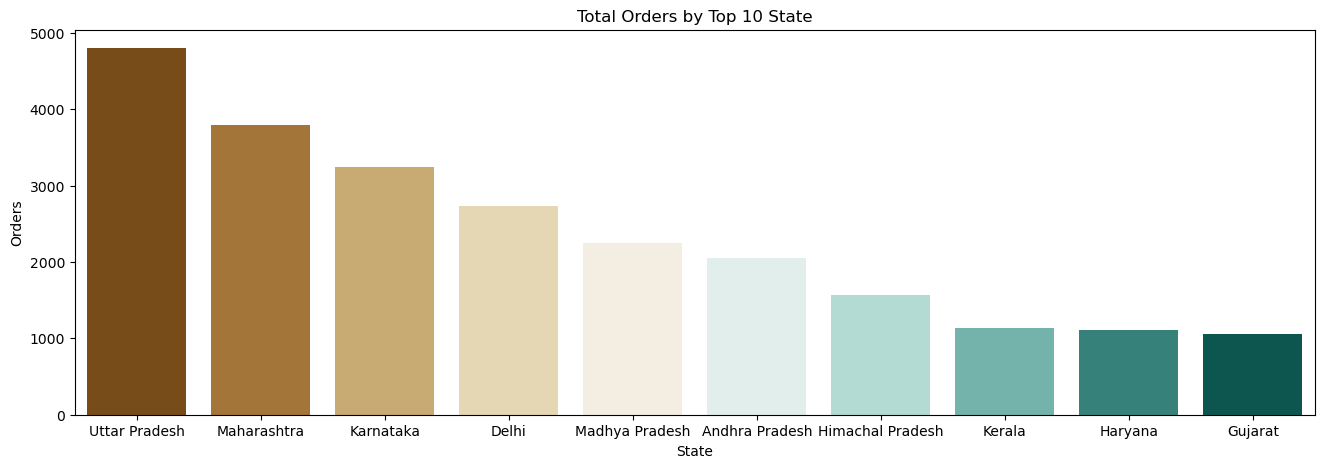

In [67]:

plt.figure(figsize = (16,5))
top_10_states = df.groupby(['State'], as_index = False)['Orders'].sum().sort_values(by = 'Orders', ascending = False).head(10)

sns.barplot(data = top_10_states, x = 'State', y = 'Orders', hue = 'State', palette = 'BrBG')

plt.title('Total Orders by Top 10 State')
plt.show()

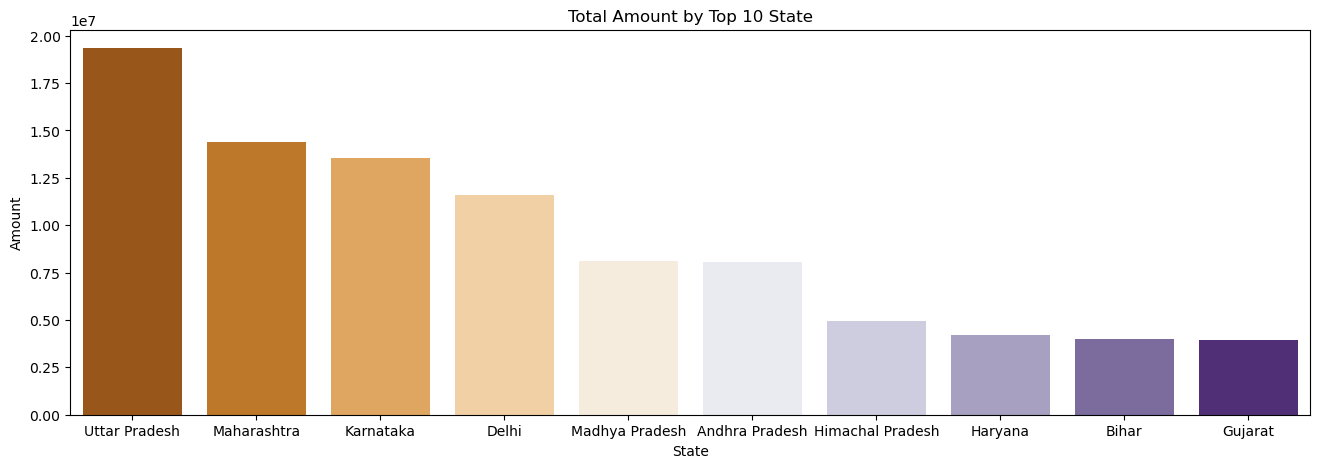

In [69]:
plt.figure(figsize = (16,5))
top_10_states = df.groupby(['State'], as_index = False)['Amount'].sum().sort_values(by = 'Amount', ascending = False).head(10)

sns.barplot(data = top_10_states, x = 'State', y = 'Amount', hue = 'State', palette = 'PuOr')

plt.title('Total Amount by Top 10 State')
plt.show()

*From the above charts we can analyse that most of our orders and revenue are coming from Uttar Pradesh, Maharashtra and Karnataka respectively*

## Analysis by Marital Status

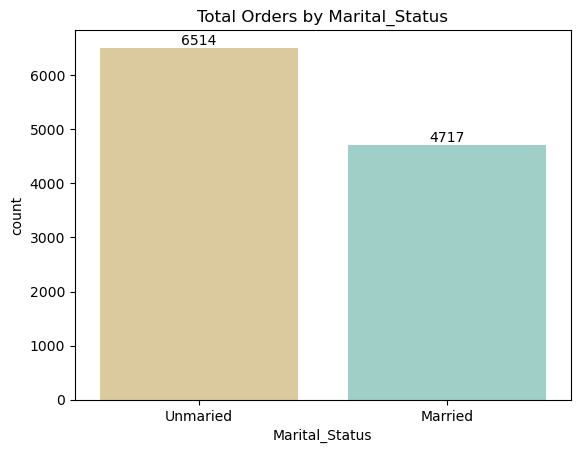

In [74]:
ax = sns.countplot(x = 'Marital_Status', data = df, hue = 'Marital_Status', palette = 'BrBG')
for bars in ax.containers:
    ax.bar_label(bars)

plt.title('Total Orders by Marital_Status')
plt.show()

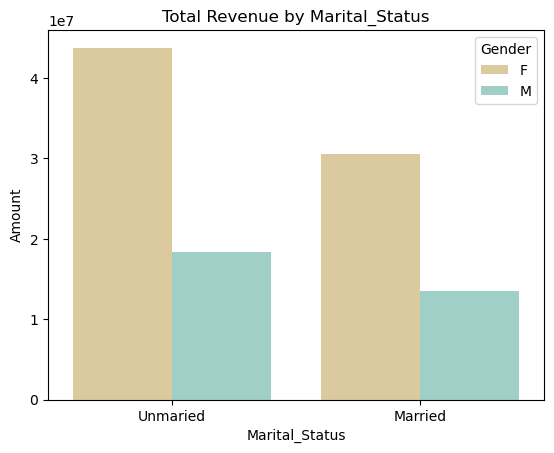

In [77]:
Sales_by_marital_status = df.groupby(['Marital_Status','Gender'], as_index = False)['Amount'].sum().sort_values(by = 'Amount', ascending = False)
sns.barplot(x = 'Marital_Status', y = 'Amount', data = Sales_by_marital_status, hue = 'Gender', palette = 'BrBG')

plt.title('Total Revenue by Marital_Status')
plt.show()

*From above graphs we can see that most of the buyers are Unmarried (women) and they have high purchasing power*

### Analysis by Occupation

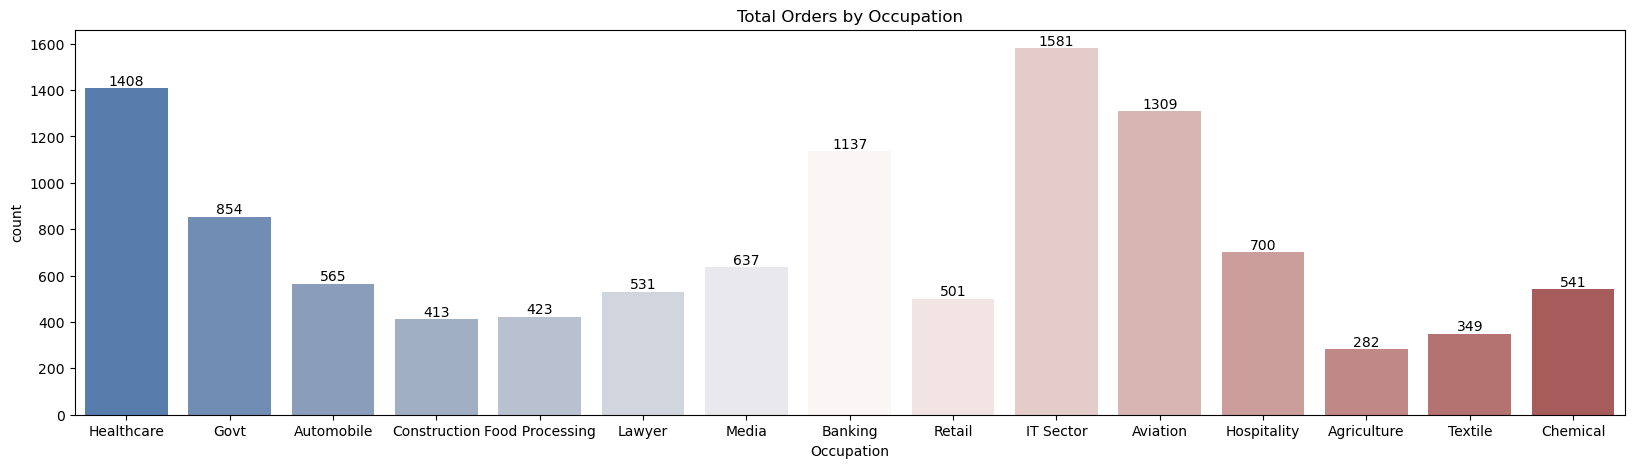

In [81]:
plt.figure(figsize = (20,5))
ax = sns.countplot(x = 'Occupation', data = df, hue = 'Occupation', palette = 'vlag')
for bars in ax.containers:
    ax.bar_label(bars)
plt.title('Total Orders by Occupation')
plt.show()

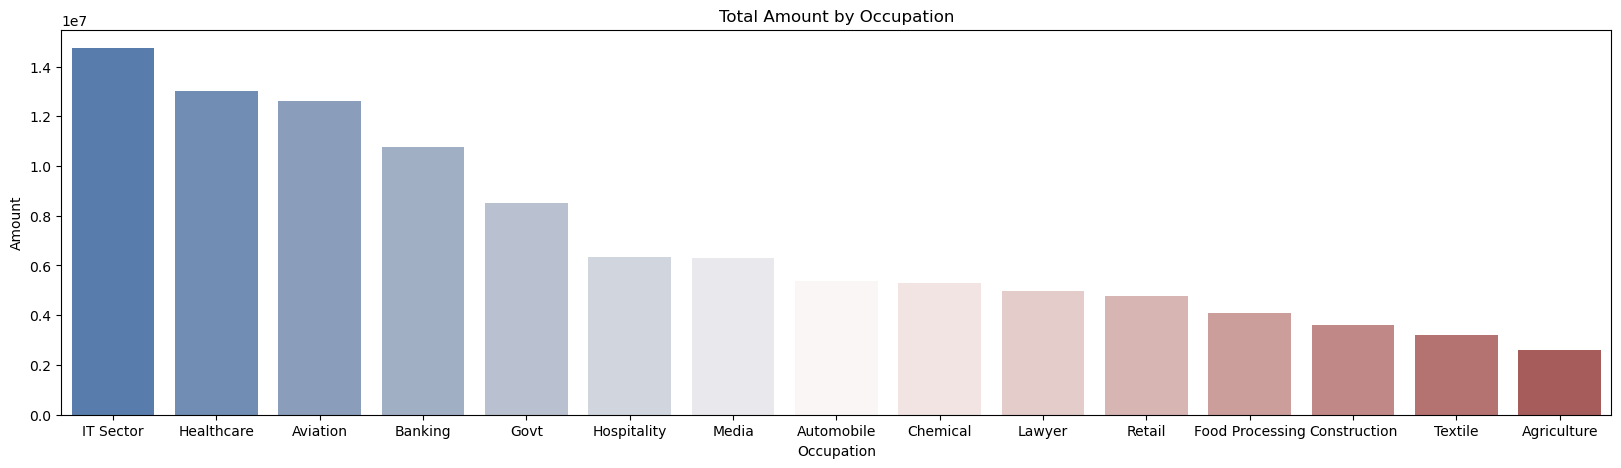

In [83]:

plt.figure(figsize = (20,5))
sales_by_occupation = df.groupby(['Occupation'], as_index = False)['Amount'].sum().sort_values(by = 'Amount', ascending = False)
sns.barplot(data = sales_by_occupation, x= 'Occupation', y='Amount', hue = 'Occupation', palette = 'vlag')

plt.title('Total Amount by Occupation')
plt.show()

*From above graphs we can see that most of the buyers are working in IT, Healthcare and Aviation sector*

### Analysis by Products and Product_category

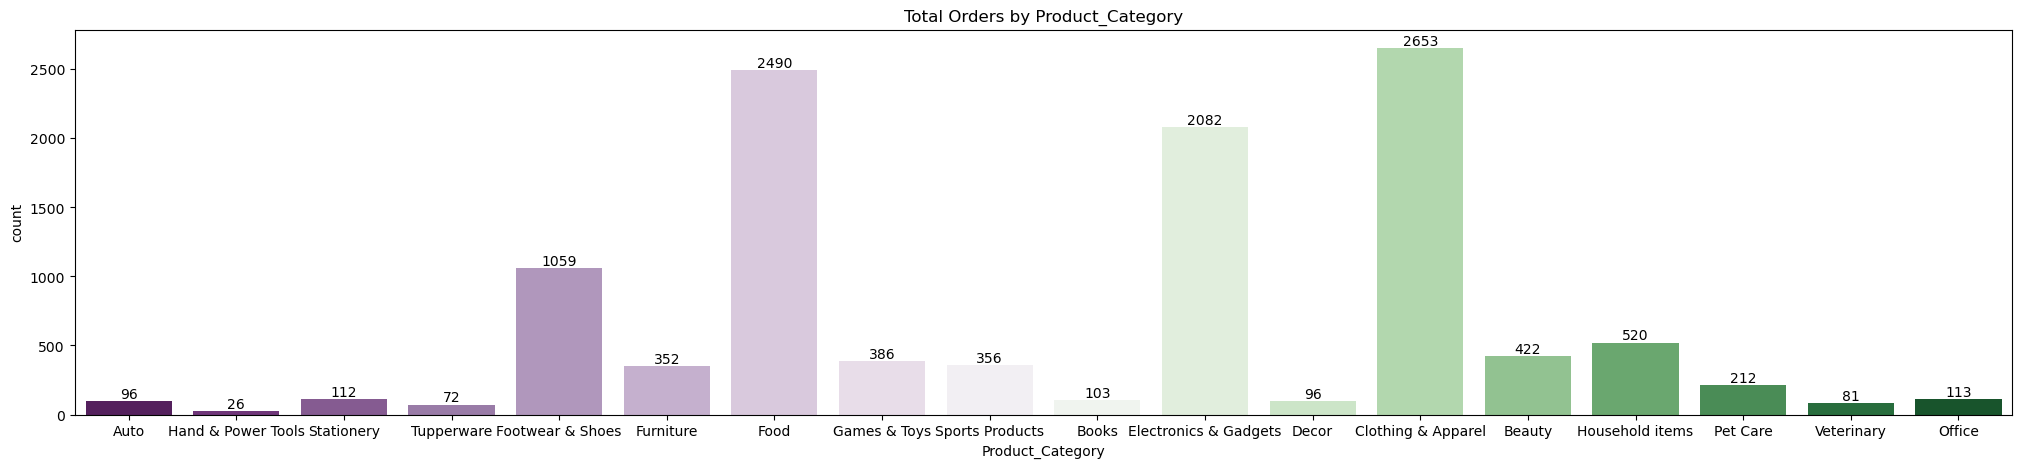

In [87]:
plt.figure(figsize = (25,5))
ax = sns.countplot(x = 'Product_Category', data = df, hue = 'Product_Category', palette = 'PRGn')
for bars in ax.containers:
    ax.bar_label(bars)
plt.title('Total Orders by Product_Category')
plt.show()

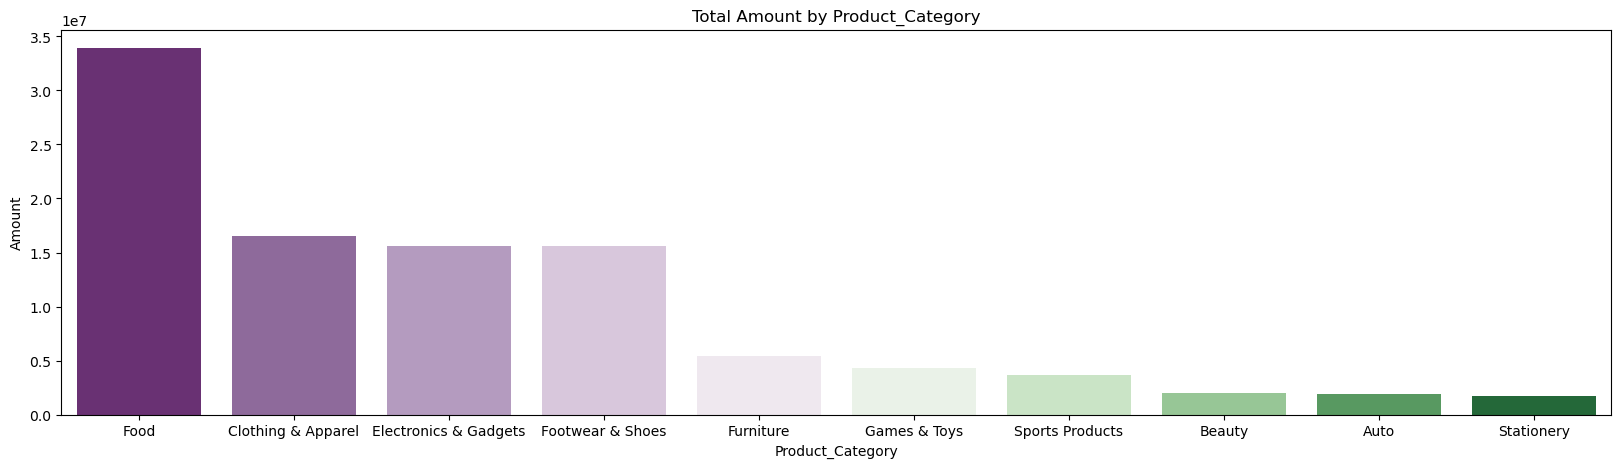

In [92]:
plt.figure(figsize = (20,5))
sales_by_category = df.groupby(['Product_Category'], as_index = False)['Amount'].sum().sort_values(by = 'Amount', ascending = False).head(10)
sns.barplot(data = sales_by_category, x= 'Product_Category', y='Amount', hue = 'Product_Category', palette = 'PRGn')

plt.title('Total Amount by Product_Category')
plt.show()

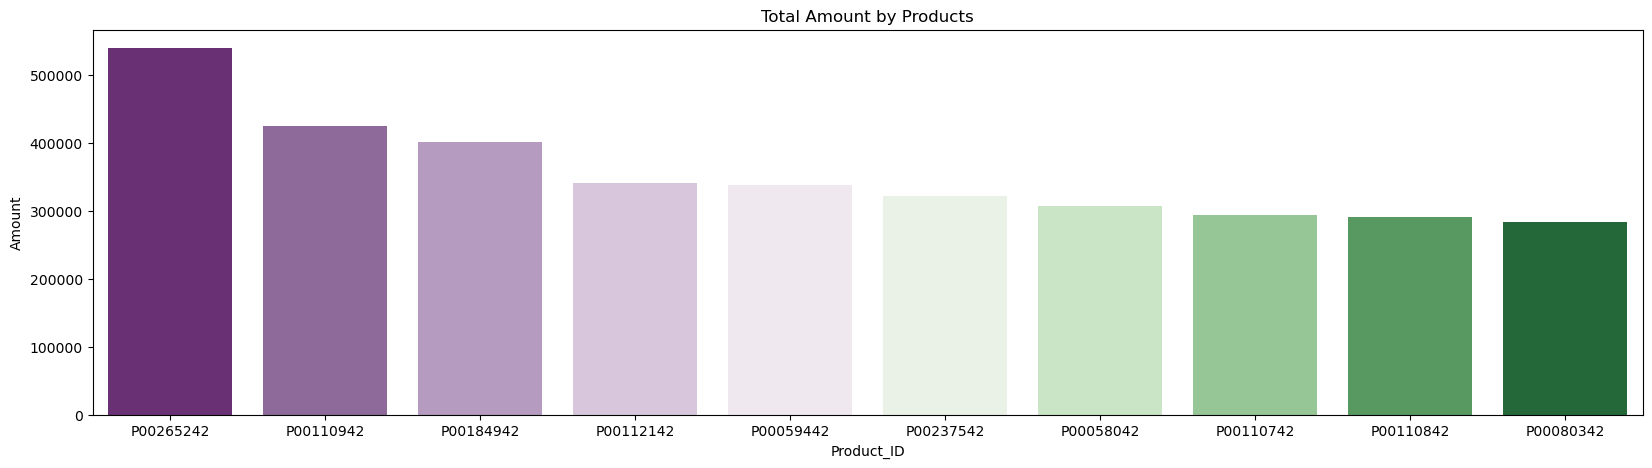

In [95]:
plt.figure(figsize = (20,5))
sales_by_products = df.groupby(['Product_ID'], as_index = False)['Amount'].sum().sort_values(by = 'Amount', ascending = False).head(10)
sns.barplot(data = sales_by_products, x= 'Product_ID', y='Amount', hue = 'Product_ID', palette = 'PRGn')

plt.title('Total Amount by Products')
plt.show()

*From above graphs we can see that most prefrred products are in Food, Clothing and Electronics*

# Conclusion

#### *Unmarried women of age group 26-35 yrs and mostly from UP, Maharastra and Karnataka and working in IT, Healthcare and Aviation are more likely to buy products from Food, Clothing and Electronics category*